# Behaviour-versus-Dimension Audit of Wearable-Classified Articles

Screening validation established a false-discovery rate of roughly 40% at the target
recall, and the dominant false-positive pattern throughout this project has been the
behaviour-versus-dimension boundary: articles that use a sensor to measure pedestrian
*behaviour* (step counts, physical activity, GPS trajectories, gait speed) rather than
a *built-environment attribute*. Manual inspection of the wearable-classified subset
indicates this residual contamination is concentrated there, which is expected --
wearables are the modality most strongly associated with behavioural measurement in
the literature.

This notebook applies the multi-class zero-shot classifier already developed for the
screening stage to that subset specifically, scoring each article against the target
category and the competing near-miss categories, and flags those whose strongest
match is a behavioural or otherwise out-of-scope category.

# 1. Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from transformers import pipeline

pd.set_option("display.max_colwidth", 200)
sns.set(style="whitegrid")
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"font.family": "Times New Roman"})

DEVICE = 0 if torch.cuda.is_available() else -1
print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


# 2. Load the Classified Corpus

In [2]:
df = pd.read_json("../data/06_4_dimensions_with_sensor_types.json")
df["macro_sensor_types"] = df["macro_sensor_types"].apply(lambda x: x if isinstance(x, list) else [])
df["macro_dimensions"] = df["macro_dimensions"].apply(lambda x: x if isinstance(x, list) else [])

TARGET_SENSOR_CATEGORY = "Wearable and Mobile Sensing"

audit_mask = df["macro_sensor_types"].apply(lambda x: TARGET_SENSOR_CATEGORY in x)
df_audit = df[audit_mask].copy().reset_index(drop=True)

print(f"Total articles in corpus: {len(df)}")
print(f"Articles classified as '{TARGET_SENSOR_CATEGORY}': {len(df_audit)}")

Total articles in corpus: 737
Articles classified as 'Wearable and Mobile Sensing': 75


# 3. Multi-Class Near-Miss Classifier

The same category definitions used at the screening stage, scored independently
(`multi_label=True`) so that each hypothesis is evaluated on its own rather than
competing for a shared probability mass.

In [3]:
zeroshot_classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-large-zeroshot-v2.0-c",
    device=DEVICE,
)

MULTICLASS_LABELS = {
    "target": "uses sensor data to measure a walkability dimension of the built environment",
    "behavior_outcome": "uses sensor or wearable data to measure pedestrian behavior or "
                         "physical activity, such as steps, GPS trajectories, or active travel",
    "clinical_outcome": "measures gait, mobility impairment, or rehabilitation outcomes in "
                         "patients as a clinical or health assessment",
    "wrong_construct": "uses sensor or imagery data to assess crime risk, collision risk, "
                        "or property value, not walkability",
    "no_sensor": "assesses walkability using surveys, self-report, or perception "
                 "questionnaires, with no sensor or imagery instrument",
    "wrong_population": "studies cyclists or vehicle drivers rather than pedestrians",
}
MULTICLASS_ORDER = list(MULTICLASS_LABELS.keys())
MULTICLASS_TEXTS = list(MULTICLASS_LABELS.values())

def multiclass_scores(text):
    if not isinstance(text, str) or not text.strip():
        return {label: np.nan for label in MULTICLASS_TEXTS}
    result = zeroshot_classifier(
        text,
        candidate_labels=MULTICLASS_TEXTS,
        hypothesis_template="This article {}.",
        multi_label=True,
    )
    return dict(zip(result["labels"], result["scores"]))

Device set to use cuda:0


> A `clinical_outcome` category is added to the screening-stage set. Manual inspection
> of this subset surfaced rehabilitation and gait-assessment studies (post-stroke
> ambulation, mobility impairment in older adults) that are distinct from the general
> behavioural pattern and were not represented among the original near-miss categories.

# 4. Score the Subset

In [4]:
tqdm.pandas(desc=f"Scoring {TARGET_SENSOR_CATEGORY} subset")
raw_scores = df_audit["introduction"].progress_apply(multiclass_scores)

for key in MULTICLASS_ORDER:
    df_audit[f"mc_{key}"] = raw_scores.apply(lambda d: d.get(MULTICLASS_LABELS[key], np.nan))

competing_cols = [f"mc_{k}" for k in MULTICLASS_ORDER if k != "target"]
df_audit["margin"] = df_audit["mc_target"] - df_audit[competing_cols].max(axis=1)
df_audit["strongest_competitor"] = df_audit[competing_cols].idxmax(axis=1).str.replace("mc_", "", regex=False)

print(df_audit[["mc_target"] + competing_cols + ["margin"]].describe().round(3))

Scoring Wearable and Mobile Sensing subset:   0%|          | 0/75 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


       mc_target  mc_behavior_outcome  mc_clinical_outcome  \
count     75.000               75.000               75.000   
mean       0.270                0.659                0.129   
std        0.324                0.337                0.180   
min        0.004                0.020                0.017   
25%        0.041                0.332                0.050   
50%        0.103                0.833                0.078   
75%        0.429                0.948                0.129   
max        0.998                0.998                0.949   

       mc_wrong_construct  mc_no_sensor  mc_wrong_population  margin  
count              75.000        75.000               75.000  75.000  
mean                0.035         0.063                0.042  -0.425  
std                 0.074         0.126                0.140   0.359  
min                 0.001         0.000                0.000  -0.965  
25%                 0.006         0.001                0.004  -0.803  
50%            

# 5. Flag Out-of-Scope Articles

In [5]:
# An article is flagged when a competing near-miss category outscores the target
# category -- i.e. a negative margin.
df_audit["flagged"] = df_audit["margin"] < 0

n_flagged = int(df_audit["flagged"].sum())
print(f"Articles flagged as out of scope: {n_flagged} / {len(df_audit)} "
      f"({n_flagged / len(df_audit) * 100:.1f}%)")

print("\nStrongest competing category among flagged articles:")
print(df_audit.loc[df_audit["flagged"], "strongest_competitor"].value_counts())

Articles flagged as out of scope: 70 / 75 (93.3%)

Strongest competing category among flagged articles:
strongest_competitor
behavior_outcome    56
no_sensor            6
clinical_outcome     4
wrong_population     3
wrong_construct      1
Name: count, dtype: int64


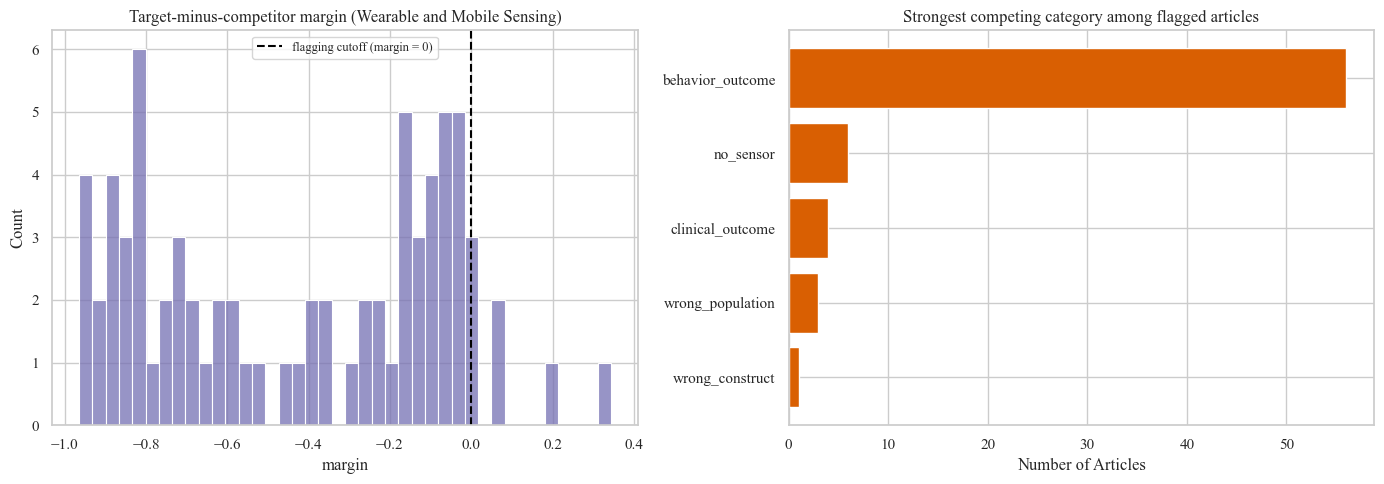

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_audit["margin"].dropna(), bins=40, ax=axes[0], color="#7570b3")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.5, label="flagging cutoff (margin = 0)")
axes[0].set_title(f"Target-minus-competitor margin ({TARGET_SENSOR_CATEGORY})")
axes[0].set_xlabel("margin")
axes[0].legend(fontsize=9)

competitor_counts = df_audit.loc[df_audit["flagged"], "strongest_competitor"].value_counts()
axes[1].barh(competitor_counts.index[::-1], competitor_counts.values[::-1], color="#d95f02")
axes[1].set_title("Strongest competing category among flagged articles")
axes[1].set_xlabel("Number of Articles")

plt.tight_layout()
plt.show()

# 6. Inspect Flagged Articles

In [7]:
inspection_sample = df_audit[df_audit["flagged"]].nsmallest(15, "margin")

for _, row in inspection_sample.iterrows():
    print(f"DOI: {row.get('doi', 'N/A')}")
    print(f"Margin: {row['margin']:.3f} | Strongest competitor: {row['strongest_competitor']} "
          f"({row[f'mc_' + row['strongest_competitor']]:.3f}) | Target: {row['mc_target']:.3f}")
    print((row["introduction"] or "")[:300])
    print("-" * 100)

DOI: 10.1016/j.healthplace.2021.102602
Margin: -0.965 | Strongest competitor: behavior_outcome (0.988) | Target: 0.022
Studies often rely on home locations to access built environment (BE) influences on physical activity (PA). We use GPS and accelerometer data collected for 288 individuals over a two-week period to examine eight GPS-derived BE characteristics and moderate-to-vigorous PA (MVPA) and light-to-moderate-
----------------------------------------------------------------------------------------------------
DOI: 10.1016/j.envres.2023.116864
Margin: -0.962 | Strongest competitor: behavior_outcome (0.966) | Target: 0.004
Background: Inconsistent results have been found in the literature on associations of greenness, or vegetation quantity, and physical activity. However, few studies have assessed associations between mobility-based greenness and physical activity from mobile health data from smartphone and wearable 
----------------------------------------------------------------

# 7. Save the Audit Result

Both files are written: the audited corpus with the flag and all category scores
retained for inspection, and the corpus with flagged articles removed from the
wearable category. Downstream co-occurrence analysis should be re-run against the
filtered file.

In [8]:
df_audit.to_json("../data/06_5_wearable_audit_scores.json", orient="records", indent=4)

flagged_dois = set(df_audit.loc[df_audit["flagged"], "doi"])

def remove_flagged_sensor(row):
    if row["doi"] in flagged_dois:
        return [s for s in row["macro_sensor_types"] if s != TARGET_SENSOR_CATEGORY]
    return row["macro_sensor_types"]

df_filtered = df.copy()
df_filtered["macro_sensor_types"] = df_filtered.apply(remove_flagged_sensor, axis=1)
df_filtered.to_json("../data/06_6_dimensions_with_sensor_types_audited.json", orient="records", indent=4)

n_before = int(df["macro_sensor_types"].apply(lambda x: TARGET_SENSOR_CATEGORY in x).sum())
n_after = int(df_filtered["macro_sensor_types"].apply(lambda x: TARGET_SENSOR_CATEGORY in x).sum())
n_no_sensor_now = int((df_filtered["macro_sensor_types"].str.len() == 0).sum())

print(f"'{TARGET_SENSOR_CATEGORY}' articles before audit: {n_before}")
print(f"'{TARGET_SENSOR_CATEGORY}' articles after audit: {n_after}")
print(f"Articles now left with no sensor category at all: {n_no_sensor_now}")
print("\nSaved:")
print("  ../data/06_5_wearable_audit_scores.json")
print("  ../data/06_6_dimensions_with_sensor_types_audited.json")

'Wearable and Mobile Sensing' articles before audit: 75
'Wearable and Mobile Sensing' articles after audit: 5
Articles now left with no sensor category at all: 425

Saved:
  ../data/06_5_wearable_audit_scores.json
  ../data/06_6_dimensions_with_sensor_types_audited.json
